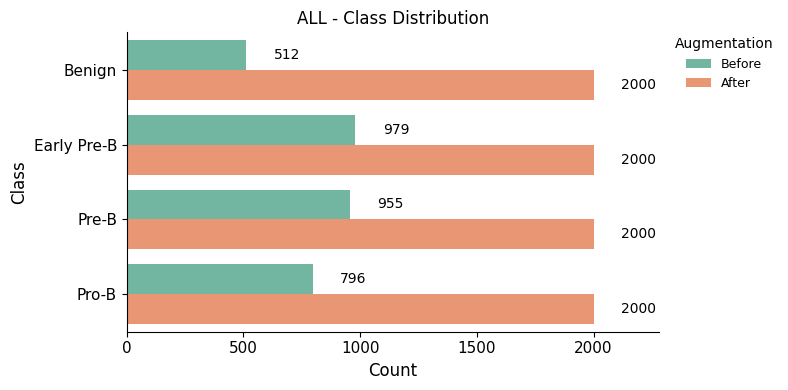

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ======== MANUAL CLASS COUNTS =========
before_aug = {
    "Benign": 512,
    "Early Pre-B": 979,
    "Pre-B": 955,
    "Pro-B": 796
}

after_aug = {
    "Benign": 2000,
    "Early Pre-B": 2000,
    "Pre-B": 2000,
    "Pro-B": 2000
}

# Prepare DataFrame for seaborn
classes = list(before_aug.keys())
plot_data = []
for cls in classes:
    plot_data.append({"Class": cls, "Count": before_aug[cls], "Augmentation": "Before"})
    plot_data.append({"Class": cls, "Count": after_aug[cls],  "Augmentation": "After"})
df = pd.DataFrame(plot_data)

# ======== PLOTTING ========
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df, x="Count", y="Class", hue="Augmentation", palette="Set2")

plt.title("ALL - Class Distribution", fontsize=12)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Class", fontsize=12)
plt.tick_params(axis='both', labelsize=11)
sns.despine()

# --- make room on the right so annotations + outside legend won't overlap ---
max_count = df["Count"].max()
right_buffer = max_count * 0.14   # 14% of max count as buffer (tweakable)
plt.xlim(0, max_count + right_buffer)

# --- annotate bars: put labels just to the right of each bar using data coords ---
shift = max_count * 0.01  # shift for annotation (1% of max_count)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(shift, 0),
            textcoords='offset points',  # offset in points from xy
            ha='left',
            va='center',
            fontsize=10
        )

# --- move legend outside top-right of the axes (so it won't overlap) ---
# bbox_to_anchor=(1.02, 1) places the legend just outside the right border at the top
ax.legend(title='Augmentation', loc='upper left', bbox_to_anchor=(1.02, 1), 
          borderaxespad=0, fontsize=9, title_fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig("all_distribution.png", bbox_inches='tight')
plt.show()
